# Rabi Oscillations

## Overview

In this notebook we demonstrate Rabi oscillations using the circuit model of quantum computing.

We will:

1. Review the theoretical expression for excited-state probability.
2. Implement a single-qubit rotation $R_x(\theta)$.
3. Compare analytic and simulated probabilities.
4. Explore the effect of noise such as T1 relaxation.
5. Estimate execution cost on quantum hardware.

The goal is to connect the physical concept of driven two-level dynamics with its circuit-level implementation.

## Physical Background

Rabi oscillations describe the coherent oscillation of population between the ground and excited states of a two-level quantum system under a resonant drive. In the rotating frame, the evolution of a driven qubit can be represented as a rotation on the Bloch sphere.

If the qubit starts in the ground state and is driven resonantly, the probability of measuring the excited state oscillates as

P(|1⟩) = sin²(θ / 2)

where θ is the rotation angle induced by the drive. In this notebook, the rotation angle θ plays the role of time under a constant drive. Sweeping θ therefore simulates the time evolution of a driven two-level system and produces Rabi oscillations.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from braket.devices import LocalSimulator
from braket.tracking import Tracker
from braket.circuits import Circuit, ResultType

from braket.experimental.algorithms.rabi_oscillations import rabi_probability, rabi_circuit


tracker = Tracker().start()  # to track Braket costs

## Constructing the Circuit

We simulate Rabi oscillations using single-qubit rotations. A rotation around the x-axis corresponds to a resonant drive applied to the qubit.

For a given rotation angle θ, we apply an Rx(θ) gate to the qubit and then measure it. Measuring the qubit after the rotation allows us to estimate the probability of finding the qubit in the excited state, which corresponds to the excited-state population in the Rabi oscillation model.

By sweeping the rotation angle θ over a range of values, we can simulate the oscillatory behavior of the excited-state population.

In [2]:
theta_example = np.pi / 3
circ = rabi_circuit(theta_example)
print(circ.diagram())


T  : │     0      │
      ┌──────────┐ 
q0 : ─┤ Rx(1.05) ├─
      └──────────┘ 
T  : │     0      │


## Sweeping the Rotation Angle

We vary $\theta$ from $0$ to $2\pi$ and compute the expected analytic probability.

In [3]:
# Sweep angles from 0 to 2π
thetas = np.linspace(0, 2 * np.pi, 101)

# Analytic prediction
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

## Ideal Simulation (Exact Probability)

Using the simulator in analytic mode (`shots=0`), we compute the exact excited-state probability.

In [4]:
device = LocalSimulator()

def p1_from_result_type(theta: float) -> float:
    circ = rabi_circuit(theta)
    circ.add_result_type(ResultType.Probability(target=[0]))
    task = device.run(circ, shots=0)  # analytic mode
    result = task.result()
    probs = result.result_types[0].value  # [P(|0>), P(|1>)]
    return float(probs[1])

p1_sim_exact = np.array([p1_from_result_type(theta) for theta in thetas])

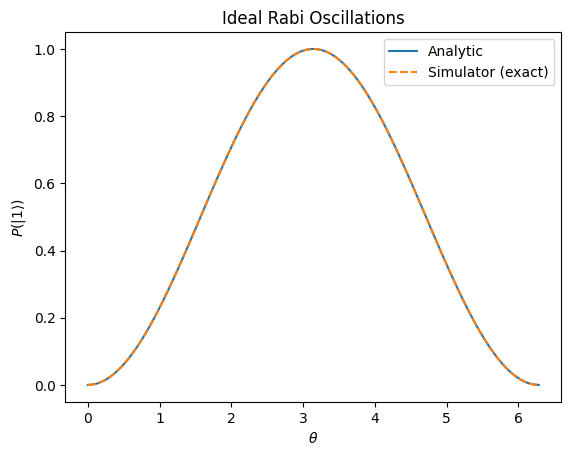

In [5]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_exact, linestyle="--", label="Simulator (exact)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Ideal Rabi Oscillations")
plt.legend()
plt.show()

### Interpretation

The simulator result matches the analytic curve exactly. This confirms that the circuit correctly implements the rotation $R_x(\theta)$ and reproduces ideal Rabi oscillations.

## Sampled Simulation (Finite Shots)

In practice, measurements are sampled. We now estimate the probability using a finite number of shots.

In [6]:
def p1_from_sampling(theta: float, shots: int = 1000) -> float:
    circ = rabi_circuit(theta)
    task = device.run(circ, shots=shots)
    result = task.result()
    counts = result.measurement_counts  # dict like {"0": n0, "1": n1}
    n1 = counts.get("1", 0)
    return n1 / shots

shots = 1000
p1_sim_sampled = np.array([p1_from_sampling(theta, shots=shots) for theta in thetas])

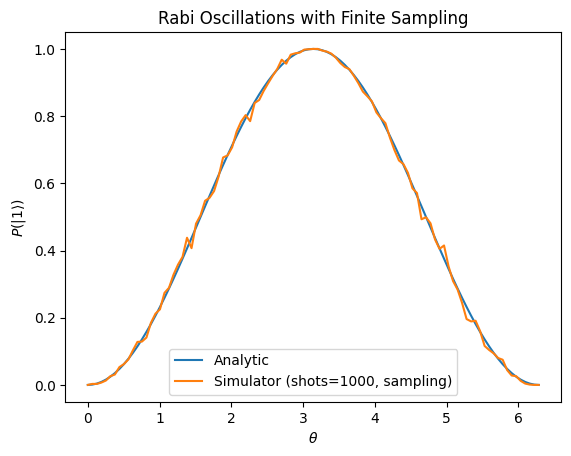

In [7]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_sampled, label=f"Simulator (shots={shots}, sampling)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with Finite Sampling")
plt.legend()
plt.show()

### Interpretation

With a finite number of shots, the estimated probabilities fluctuate around the ideal curve due to sampling noise. Increasing the number of shots would reduce these fluctuations and produce a smoother estimate of the underlying probability curve.

## Measurement Statistics at a Specific Angle

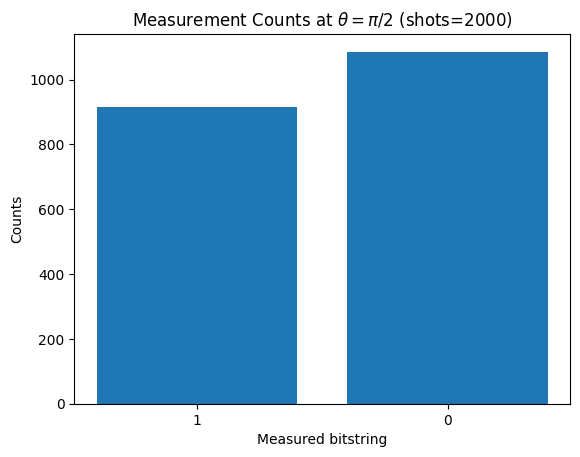

In [8]:
theta_hist = np.pi / 2
shots_hist = 2000

result = device.run(rabi_circuit(theta_hist), shots=shots_hist).result()
counts = result.measurement_counts

plt.figure()
plt.bar(list(counts.keys()), list(counts.values()))
plt.xlabel("Measured bitstring")
plt.ylabel("Counts")
plt.title(rf"Measurement Counts at $\theta=\pi/2$ (shots={shots_hist})")
plt.show()

### Interpretation

At $\theta = \pi/2$, the analytic prediction gives

$$
P(|1\rangle) = \sin^2\left(\frac{\pi}{4}\right) = \frac{1}{2}.
$$

This means the system is in an equal superposition of $|0\rangle$ and $|1\rangle$.

The histogram shows approximately equal counts for the two measurement outcomes.
Small deviations from perfect balance arise from finite sampling statistics.

As the number of shots increases, the observed distribution converges to the theoretical 50/50 split.

## T1 Relaxation: Single Damping Channel

We first model T1 relaxation using a simple circuit-level picture. After applying the rotation $R_x(\theta)$, we apply a single amplitude damping channel.

This model is easy to interpret: larger damping suppresses the excited-state population $P(|1\rangle)$, while the overall oscillation shape remains unchanged.

In [9]:
device_dm = LocalSimulator("braket_dm")

In [10]:
def rabi_circuit_t1_simple(theta: float, gamma: float) -> Circuit:
    circ = Circuit()
    circ.rx(0, theta)
    circ.amplitude_damping(0, gamma)
    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [11]:
def p1_from_t1_simple(theta: float, gamma: float) -> float:
    circ = rabi_circuit_t1_simple(theta, gamma)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [12]:
gamma_values_t1_simple = [0.02, 0.1, 0.5]

p1_t1_simple = {
    gamma: np.array([p1_from_t1_simple(theta, gamma) for theta in thetas])
    for gamma in gamma_values_t1_simple
}

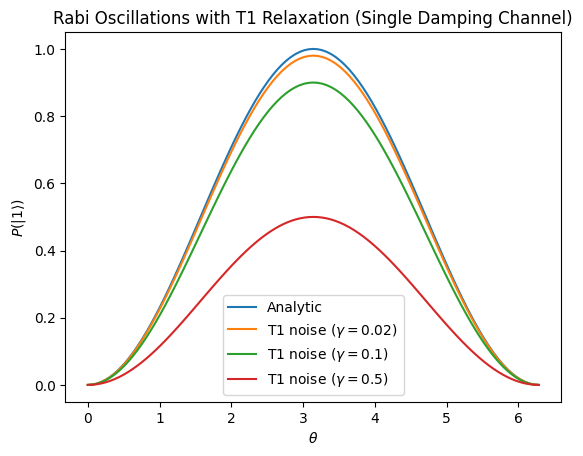

In [13]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t1_simple:
    plt.plot(thetas, p1_t1_simple[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Single Damping Channel)")
plt.legend()
plt.show()

### Interpretation

In this simple model, T1 relaxation reduces the amplitude of the Rabi oscillation. For small $\gamma$, the effect is weak, while for large $\gamma$ the excited-state population is strongly suppressed.

This is a useful first approximation, but it does not yet describe relaxation acting continuously during the driven evolution.

## T1 Relaxation: Stepwise Model

We now use a more realistic model in which the drive and the relaxation act repeatedly throughout the evolution.

To approximate continuous-time dynamics, we divide the total rotation into many small steps. After each small rotation, we apply a small amplitude damping channel. This allows the coherent drive and the T1 process to compete during the evolution.

In [14]:
import math
from braket.circuits import Circuit, ResultType

def rabi_circuit_t1_stepwise(theta: float, gamma: float, dtheta: float = 0.1) -> Circuit:
    circ = Circuit()

    # number of steps needed
    n_steps = max(1, math.ceil(theta / dtheta))

    # adjust step size so steps sum exactly to theta
    dtheta_eff = theta / n_steps
    gamma_step = gamma * dtheta_eff

    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.amplitude_damping(0, gamma_step)

    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [15]:
def p1_from_t1_stepwise(theta: float, gamma: float = 0.1) -> float:
    circ = rabi_circuit_t1_stepwise(theta, gamma)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [16]:
thetas = np.linspace(0, 8 * np.pi, 300)
gamma_values_t1_stepwise = [0.02, 0.1, 0.5]
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

p1_t1_stepwise = {
    gamma: np.array([p1_from_t1_stepwise(theta, gamma) for theta in thetas])
    for gamma in gamma_values_t1_stepwise
}

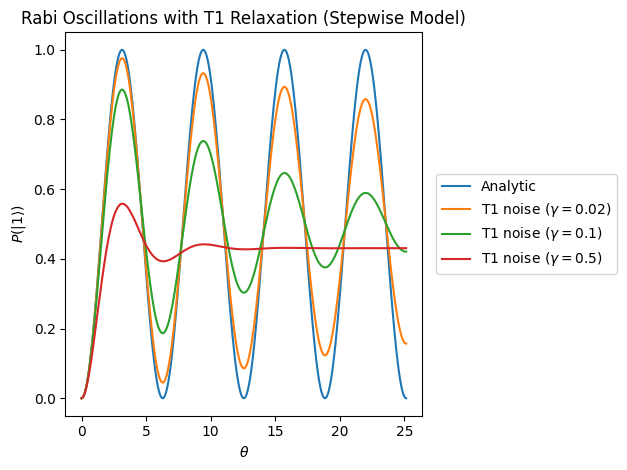

In [17]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t1_stepwise:
    plt.plot(thetas, p1_t1_stepwise[gamma], label=fr"T1 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T1 Relaxation (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

In the stepwise model, T1 relaxation acts continuously during the driven evolution rather than only once at the end.

As a result, the oscillation is not only suppressed but also distorted by the repeated competition between excitation and relaxation. This provides a more realistic picture of driven open-system dynamics.

## T2 Dephasing: Stepwise Model

We now turn to **T2 dephasing**, which describes loss of phase coherence without direct energy relaxation.

As in the T1 stepwise model, we divide the evolution into many small steps. In each step, we apply a small rotation followed by a small phase damping channel. This lets the coherent drive and the dephasing process act together throughout the evolution.

Unlike T1 relaxation, T2 dephasing does not directly drive the qubit toward the ground state. Instead, it reduces the coherence responsible for the oscillation, so the Rabi oscillations gradually lose contrast as the dephasing strength increases.

In [18]:

def rabi_circuit_t2_stepwise(theta: float, gamma: float, dtheta: float = 0.1) -> Circuit:
    circ = Circuit()

    n_steps = max(1, math.ceil(theta / dtheta))
    dtheta_eff = theta / n_steps
    gamma_step = gamma * dtheta_eff

    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.phase_damping(0, gamma_step)

    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [19]:
def p1_from_t2_stepwise(theta: float, gamma: float, dtheta: float = 0.1) -> float:
    circ = rabi_circuit_t2_stepwise(theta, gamma, dtheta=dtheta)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [20]:
thetas = np.linspace(0, 8 * np.pi, 300)
gamma_values_t2 = [0.02, 0.1, 0.5]
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

p1_t2_stepwise = {
    gamma: np.array([p1_from_t2_stepwise(theta, gamma) for theta in thetas])
    for gamma in gamma_values_t2
}

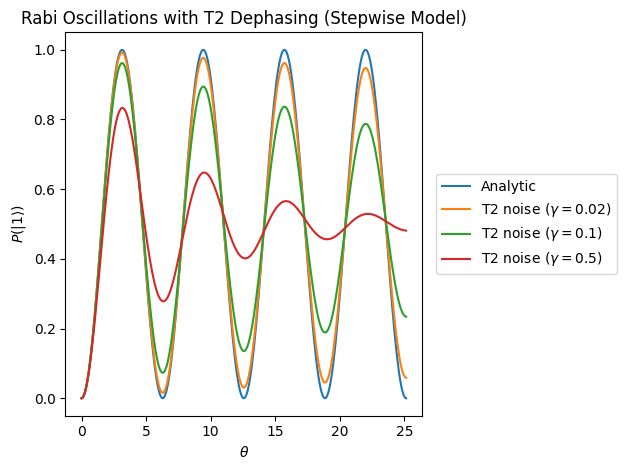

In [21]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma in gamma_values_t2:
    plt.plot(thetas, p1_t2_stepwise[gamma], label=fr"T2 noise ($\gamma={gamma}$)")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with T2 Dephasing (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

In the stepwise T2 model, the oscillations gradually lose contrast because phase coherence is lost during the driven evolution.

For weak dephasing, the oscillations remain close to the ideal curve. As the dephasing strength increases, the oscillations are progressively washed out, while the behavior remains distinct from T1 relaxation because T2 primarily destroys coherence rather than removing population from the excited state.

## Combined T1 and T2 Noise

So far we have considered T1 relaxation and T2 dephasing separately. In realistic quantum devices, both processes occur simultaneously.

We again use the stepwise approach. For each small step of the driven evolution, we apply a small rotation representing the drive, followed by amplitude damping for T1 relaxation and phase damping for T2 dephasing. This allows both energy relaxation and dephasing to act continuously during the Rabi oscillation.

When both T1 and T2 are present, the oscillations typically decay faster than with either process alone. T1 relaxation reduces the excited-state population, while T2 dephasing reduces the coherence responsible for the oscillations.

In [22]:
def rabi_circuit_t1_t2_stepwise(
    theta: float,
    gamma_t1: float,
    gamma_t2: float,
    dtheta: float = 0.1,
) -> Circuit:
    circ = Circuit()

    n_steps = max(1, math.ceil(theta / dtheta))
    dtheta_eff = theta / n_steps

    gamma_t1_step = gamma_t1 * dtheta_eff
    gamma_t2_step = gamma_t2 * dtheta_eff

    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.amplitude_damping(0, gamma_t1_step)
        circ.phase_damping(0, gamma_t2_step)

    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ

In [23]:
def p1_from_t1_t2_stepwise(
    theta: float,
    gamma_t1: float,
    gamma_t2: float,
    dtheta: float = 0.1,
) -> float:
    circ = rabi_circuit_t1_t2_stepwise(theta, gamma_t1, gamma_t2, dtheta=dtheta)
    task = device_dm.run(circ, shots=0)
    result = task.result()
    probs = result.result_types[0].value
    return float(probs[1])

In [24]:
gamma_t1 = 0.1
gamma_t2_values = [0.05, 0.1, 0.2]

p1_t1_t2_stepwise = {
    gamma_t2: np.array(
        [p1_from_t1_t2_stepwise(theta, gamma_t1, gamma_t2) for theta in thetas]
    )
    for gamma_t2 in gamma_t2_values
}

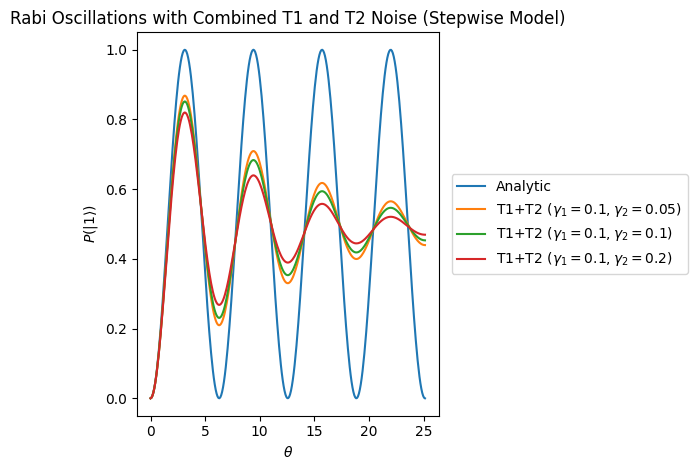

In [25]:
plt.figure()

plt.plot(thetas, p1_analytic, label="Analytic")
for gamma_t2 in gamma_t2_values:
    plt.plot(
        thetas,
        p1_t1_t2_stepwise[gamma_t2],
        label=fr"T1+T2 ($\gamma_1={gamma_t1}, \gamma_2={gamma_t2}$)",
    )

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with Combined T1 and T2 Noise (Stepwise Model)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

### Interpretation

With both T1 and T2 noise present, the Rabi oscillations decay more rapidly than in the individual noise cases. The amplitude decreases due to both relaxation and dephasing, and the oscillations gradually disappear as the system approaches a noisy steady-state behavior.

This combined model provides a more realistic picture of qubit dynamics under continuous driving in the presence of environmental noise.

## Off-Resonant Rabi Oscillations

So far we assumed the drive is resonant with the qubit transition. If the drive frequency is detuned, the qubit experiences both a coherent drive and a phase accumulation.

In the circuit model, this corresponds to combining x-rotations (drive) with z-rotations (detuning). The resulting evolution is a rotation around a tilted axis on the Bloch sphere.

As a result, the oscillations no longer reach full population transfer. Increasing detuning reduces the maximum excitation probability and modifies the oscillation frequency.

In [26]:
def rabi_circuit_off_resonant(theta: float, delta: float, dtheta: float = 0.1) -> Circuit:
    n_steps = max(1, int(math.ceil(theta / dtheta)))
    dtheta_eff = theta / n_steps
    dphi = delta * dtheta_eff

    circ = Circuit()
    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.rz(0, dphi)
    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ


def p1_from_off_resonant(theta: float, delta: float) -> float:
    circ = rabi_circuit_off_resonant(theta, delta)
    task = device.run(circ, shots=0)
    probs = task.result().result_types[0].value
    return probs[1]

In [27]:
delta_values = [0.0, 0.5, 1.0]

p1_off_resonant = {
    delta: np.array([p1_from_off_resonant(theta, delta) for theta in thetas])
    for delta in delta_values
}

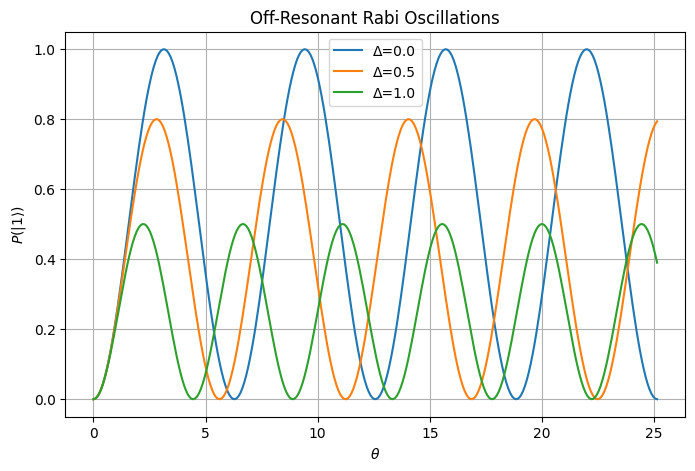

In [28]:
plt.figure(figsize=(8, 5))
for delta in delta_values:
    plt.plot(thetas, p1_off_resonant[delta], label=f"Δ={delta}")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Off-Resonant Rabi Oscillations")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

For zero detuning, the oscillations reach full population transfer. As the detuning increases, the oscillations no longer reach probability 1 and the dynamics change.

This reflects rotation around a tilted axis: detuning introduces phase accumulation, which reduces the efficiency of population transfer.

## Off-Resonant Rabi Oscillations with T1 and T2 Noise

We now combine detuning with relaxation and dephasing. In this model, the qubit experiences a driven evolution with detuning, while simultaneously undergoing amplitude damping (T1) and phase damping (T2).

This represents a more realistic scenario where both coherent effects (detuning) and incoherent noise processes (T1 and T2) are present during the evolution.

In [29]:
def rabi_circuit_off_resonant_t1_t2(
    theta: float,
    delta: float,
    gamma_t1: float,
    gamma_t2: float,
    dtheta: float = 0.1,
) -> Circuit:
    circ = Circuit()

    n_steps = max(1, math.ceil(theta / dtheta))
    dtheta_eff = theta / n_steps
    dphi = delta * dtheta_eff

    gamma_t1_step = gamma_t1 * dtheta_eff
    gamma_t2_step = gamma_t2 * dtheta_eff

    for _ in range(n_steps):
        circ.rx(0, dtheta_eff)
        circ.rz(0, dphi)
        circ.amplitude_damping(0, gamma_t1_step)
        circ.phase_damping(0, gamma_t2_step)

    circ.add_result_type(ResultType.Probability(target=[0]))
    return circ


def p1_from_off_resonant_t1_t2(
    theta: float, delta: float, gamma_t1: float, gamma_t2: float
) -> float:
    circ = rabi_circuit_off_resonant_t1_t2(theta, delta, gamma_t1, gamma_t2)
    task = device_dm.run(circ, shots=0)
    probs = task.result().result_types[0].value
    return float(probs[1])

In [30]:
delta = 0.5
gamma_t1 = 0.1
gamma_t2 = 0.1

p1_off_resonant_t1_t2 = np.array([
    p1_from_off_resonant_t1_t2(theta, delta, gamma_t1, gamma_t2)
    for theta in thetas
])

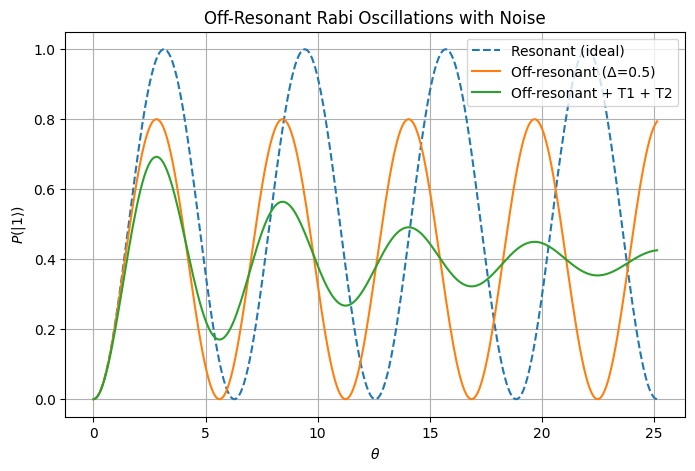

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(thetas, p1_off_resonant[0.0], label="Resonant (ideal)", linestyle="--")
plt.plot(thetas, p1_off_resonant[delta], label=f"Off-resonant (Δ={delta})")
plt.plot(thetas, p1_off_resonant_t1_t2, label="Off-resonant + T1 + T2")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Off-Resonant Rabi Oscillations with Noise")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The addition of T1 and T2 noise leads to a decay of the oscillations over time. Compared to the purely off-resonant case, the amplitude decreases further and the oscillations gradually disappear due to relaxation and dephasing.

This combined model illustrates how coherent effects such as detuning and incoherent noise processes together determine the observed qubit dynamics.

## Resource Usage and Cost Tracking

Amazon Braket provides a built-in task tracker that estimates the cost of simulator and QPU tasks based on actual execution.

Below, we display:

- A summary of tasks executed in this notebook  
- The estimated total cost based on those tasks  

Note: These values are estimates and depend on actual device usage and current pricing.

In [32]:
print("Task Summary")
print(f"{tracker.quantum_tasks_statistics()} \n")
print(
    f"Estimated cost to run this example: {tracker.qpu_tasks_cost() + tracker.simulator_tasks_cost():.2f} USD"
)

Task Summary
{} 

Estimated cost to run this example: 0.00 USD


### Interpretation

For local simulations, the estimated cost is typically zero or negligible.

If executed on a QPU, costs would depend on:

- The number of tasks submitted  
- The number of measurement shots  
- The selected hardware provider  

Always consult the official Amazon Braket pricing page for current rates.

In [33]:
tracker.stop()